In [ ]:
# 1. Import function
import sys
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import keras
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import svm
from sklearn import tree
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
import sklearn.metrics
import seaborn as sns
from sklearn.metrics import accuracy_score
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# 2. Baca data
print("Membaca Data =================================================================")
data = pd.read_csv("covid-liver.csv", encoding='latin1')
df = pd.DataFrame(data)
df.head()

Membaca Data =================================================================


,Cancer,Year,Month,Bleed,Mode_Presentation,Age,Gender,Etiology,Cirrhosis,Size,...,Surveillance_programme,Surveillance_effectiveness,Mode_of_surveillance_detection,Time_diagnosis_1st_Tx,Date_incident_surveillance_scan,PS,Time_MDM_1st_treatment,Time_decisiontotreat_1st_treatment,Prev_known_cirrhosis,Months_from_last_surveillance
0,Y,Prepandemic,1,N,Surveillance,68,M,NAFLD,Y,22.0,...,Y,Consistent,US,0.47,NaN,0.0,0.7,NaN,Y,7.333333
1,Y,Prepandemic,1,N,Surveillance,70,M,ARLD,Y,40.0,...,Y,Consistent,US,NaN,NaN,2.0,NaN,NaN,Y,4.033333
2,Y,Prepandemic,1,N,Surveillance,64,M,ARLD,Y,52.0,...,Y,Consistent,US,NaN,NaN,0.0,NaN,NaN,Y,5.900000
3,Y,Prepandemic,1,N,Incidental,73,M,ARLD,Y,80.0,...,N,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Y,NaN
4,Y,Prepandemic,1,N,Incidental,66,F,ARLD,Y,60.0,...,N,NaN,NaN,NaN,NaN,0.0,NaN,NaN,Y,NaN


In [ ]:
# 3. Mengambil varibel
print("\nMengambil Variabel ================================================================")
# Menggunakan replace() untuk mengubah nilai kategori menjadi nilai numerik
df["Cancer"] = df["Cancer"].replace({
    "Y": 1,  # Change Y to 1 (assuming Y represents presence of cancer)
    "N": 0,  # Change N to 0 (assuming N represents absence of cancer)
})
print(df)

Month = df["Month"]
print(Month)

Age = df["Age"]
print(Age)

Size = df["Size"]
print(Size)

Survival = df["Survival_fromMDM"]
print(Survival)

Diagnosis = df["Time_diagnosis_1st_Tx"]
print(Diagnosis)

PS = df["PS"]
print(PS)

Time_MDM = df["Time_MDM_1st_treatment"]
print(Time_MDM)

Time_Decision = df["Time_decisiontotreat_1st_treatment"]
print(Time_Decision)

Months_Surveillance = df["Months_from_last_surveillance"]
print(Months_Surveillance)

# Tanpa data kategori (hanya data numerik)
selected_columns = df.iloc[:, [2, 5, 9, 14, 20, 22, 23, 24, 26]]
selected_columns.head


Mengambil Variabel ================================================================
     Cancer         Year  Month Bleed Mode_Presentation  Age Gender Etiology  \
0         1  Prepandemic      1     N      Surveillance   68      M    NAFLD   
1         1  Prepandemic      1     N      Surveillance   70      M     ARLD   
2         1  Prepandemic      1     N      Surveillance   64      M     ARLD   
3         1  Prepandemic      1     N        Incidental   73      M     ARLD   
4         1  Prepandemic      1     N        Incidental   66      F     ARLD   
..      ...          ...    ...   ...               ...  ...    ...      ...   
445       0     Pandemic     12   NaN       Symptomatic   72      F      NaN   
446       0     Pandemic     12   NaN       Symptomatic   63      M      NaN   
447       0     Pandemic     12   NaN       Symptomatic   79      F      NaN   
448       0     Pandemic     12   NaN       Symptomatic   84      F      NaN   
449       0     Pandemic     12   N

<bound method NDFrame.head of      Month  Age  Size  Survival_fromMDM  Time_diagnosis_1st_Tx   PS  \
0        1   68  22.0             32.73                   0.47  0.0   
1        1   70  40.0              3.03                    NaN  2.0   
2        1   64  52.0             14.97                    NaN  0.0   
3        1   73  80.0              1.40                    NaN  2.0   
4        1   66  60.0             32.50                    NaN  0.0   
..     ...  ...   ...               ...                    ...  ...   
445     12   72   NaN              1.20                    NaN  1.0   
446     12   63  75.0              9.67                   2.93  0.0   
447     12   79  63.0              1.47                    NaN  1.0   
448     12   84  65.0              1.67                    NaN  2.0   
449     12   80  45.0              7.27                   0.00  2.0   

     Time_MDM_1st_treatment  Time_decisiontotreat_1st_treatment  \
0                      0.70                                 NaN   
1                       NaN                                 NaN   
2                       NaN                                 NaN   
3                       NaN                                 NaN   
4                       NaN                                 NaN   
..                      ...                                 ...   
445                     NaN                                 NaN   
446                    1.63                                1.63   
447                     NaN                                 NaN   
448                     NaN                                 NaN   
449                     NaN                                 NaN   

     Months_from_last_surveillance  
0                         7.333333  
1                         4.033333  
2                         5.900000  
3                              NaN  
4                              NaN  
..                             ...  
445                            NaN  
446                            NaN  
447                            NaN  
448                            NaN  
449                            NaN  

[450 rows x 9 columns]>

In [ ]:
# 4. Deteksi missing value\
print("\nDeteksi missing value ================================")
missing_values = df.isnull().sum()

# Menampilkan variabel yang memiliki missing value
variables_with_missing_values = missing_values[missing_values > 0].index.tolist()
print("Variabel yang memiliki missing value:")
print(variables_with_missing_values)


Deteksi missing value ================================
Variabel yang memiliki missing value:
['Bleed', 'Etiology', 'Cirrhosis', 'Size', 'HCC_TNM_Stage', 'HCC_BCLC_Stage', 'ICC_TNM_Stage', 'Treatment_grps', 'Type_of_incidental_finding', 'Surveillance_programme', 'Surveillance_effectiveness', 'Mode_of_surveillance_detection', 'Time_diagnosis_1st_Tx', 'Date_incident_surveillance_scan', 'PS', 'Time_MDM_1st_treatment', 'Time_decisiontotreat_1st_treatment', 'Prev_known_cirrhosis', 'Months_from_last_surveillance']


In [ ]:
# 5a. Mengganti missing value dalam kolom Size dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Size dengan nilai rata-rata")
# Langkah 1
df_Size = df
# Langkah 2
rata_Size = df_Size["Size"].mean()
# Langkah 3
df_Size["Size"] = df_Size["Size"].fillna(rata_Size)
# Langkah 4
df_Size["Size"].isna().sum()
print(df_Size["Size"])

# 5b. Mengganti missing value dalam kolom Time Diagnosis dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Time Diagnosis dengan nilai rata-rata")
# Langkah 1
df_time_diagnosis = df
# Langkah 2
rata_time_diagnosis = df_Size["Time_diagnosis_1st_Tx"].mean()
# Langkah 3
df_time_diagnosis["Time_diagnosis_1st_Tx"] = df_time_diagnosis["Time_diagnosis_1st_Tx"].fillna(rata_time_diagnosis)
# Langkah 4
df_time_diagnosis["Time_diagnosis_1st_Tx"].isna().sum()
print(df_time_diagnosis["Time_diagnosis_1st_Tx"])

# 5c. Mengganti missing value dalam kolom Time MDM dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Time MDM dengan nilai rata-rata")
# Langkah 1
df_time_mdm = df
# Langkah 2
rata_time_mdm = df_Size["Time_MDM_1st_treatment"].mean()
# Langkah 3
df_time_mdm["Time_MDM_1st_treatment"] = df_time_mdm["Time_MDM_1st_treatment"].fillna(rata_time_mdm)
# Langkah 4
df_time_mdm["Time_MDM_1st_treatment"].isna().sum()
print(df_time_mdm["Time_MDM_1st_treatment"])

# 5d. Mengganti missing value dalam kolom Time Decision to Treat dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Time Decision to Treat dengan nilai rata-rata")
# Langkah 1
df_time_decision_to_treat = df
# Langkah 2
rata_time_decision_to_treat = df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"].mean()
# Langkah 3
df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"] = df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"].fillna(rata_time_decision_to_treat)
# Langkah 4
df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"].isna().sum()
print(df_time_decision_to_treat["Time_decisiontotreat_1st_treatment"])

# 5e. Mengganti missing value dalam kolom Months from Last Surveillance dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Months from Last Surveillance dengan nilai rata-rata")
# Langkah 1
df_months = df
# Langkah 2
rata_months = df_months["Months_from_last_surveillance"].mean()
# Langkah 3
df_months["Months_from_last_surveillance"] = df_months["Months_from_last_surveillance"].fillna(rata_months)
# Langkah 4
df_months["Months_from_last_surveillance"].isna().sum()
print(df_months["Months_from_last_surveillance"])

# 5f. Mengganti missing value dalam kolom Survical dengan nilai rata-rata
print("\nMengganti missing value dalam kolom Survical dengan nilai rata-rata")
# Langkah 1
df_survival = df
# Langkah 2
rata_survival = df_survival["Survival_fromMDM"].mean()
# Langkah 3
df_survival["Survival_fromMDM"] = df_survival["Survival_fromMDM"].fillna(rata_months)
# Langkah 4
df_survival["Survival_fromMDM"].isna().sum()
print(df_survival["Survival_fromMDM"])



Mengganti missing value dalam kolom Size dengan nilai rata-rata
0      22.000
1      40.000
2      52.000
3      80.000
4      60.000
        ...  
445    53.355
446    75.000
447    63.000
448    65.000
449    45.000
Name: Size, Length: 450, dtype: float64

Mengganti missing value dalam kolom Time Diagnosis dengan nilai rata-rata
0      0.47000
1     -6.57038
2     -6.57038
3     -6.57038
4     -6.57038
        ...   
445   -6.57038
446    2.93000
447   -6.57038
448   -6.57038
449    0.00000
Name: Time_diagnosis_1st_Tx, Length: 450, dtype: float64

Mengganti missing value dalam kolom Time MDM dengan nilai rata-rata
0      0.700000
1      2.385988
2      2.385988
3      2.385988
4      2.385988
         ...   
445    2.385988
446    1.630000
447    2.385988
448    2.385988
449    2.385988
Name: Time_MDM_1st_treatment, Length: 450, dtype: float64

Mengganti missing value dalam kolom Time Decision to Treat dengan nilai rata-rata
0      1.500841
1      1.500841
2      1.500841
3      1.5

In [ ]:
# 6. Outlier
print("\nOutlier =================================================================")
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Deteksi outlier untuk setiap kolom dalam selected_columns
outliers_dict = {}
for col in selected_columns.columns:
    outliers_dict[col] = detect_outliers_iqr(selected_columns[col])

# Menampilkan outlier untuk setiap kolom
for col, outliers in outliers_dict.items():
    print(f"\nOutliers for column '{col}':")
    print(outliers)


Outlier =================================================================

Outliers for column 'Month':
Series([], Name: Month, dtype: int64)

Outliers for column 'Age':
46     43
53     41
123    44
192    45
235    35
290    27
291    41
346    28
382    39
384    44
388    39
414    39
Name: Age, dtype: int64

Outliers for column 'Size':
13     150.0
32     150.0
108    150.0
145    150.0
150    200.0
193    210.0
198    150.0
225    150.0
264    220.0
267    200.0
284    210.0
291    170.0
294    150.0
298    220.0
301    220.0
304    150.0
329    190.0
379    190.0
426    150.0
Name: Size, dtype: float64

Outliers for column 'Survival_fromMDM':
Series([], Name: Survival_fromMDM, dtype: float64)

Outliers for column 'Time_diagnosis_1st_Tx':
14       12.53
53       13.57
84        6.30
113       8.40
121       9.23
134      13.03
156       6.17
340   -1434.07
345       7.00
389      12.60
Name: Time_diagnosis_1st_Tx, dtype: float64

Outliers for column 'PS':
Series([], Name: PS, dt

In [ ]:
# 7. Mengatasi Outlier
print("\nMengatasi Outlier =================================================================")
# Definisikan DataFrame selected_columns
selected_columns = df.iloc[:, [9, 20, 23, 24, 26]]  # Perbaiki indeks kolom Time Decision

# Fungsi untuk mendeteksi outlier menggunakan IQR
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Fungsi untuk menangani outliers dengan menggantinya dengan nilai batas atas/bawah
def handle_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    column = column.mask(column < lower_bound, lower_bound)
    column = column.mask(column > upper_bound, upper_bound)
    return column

# Deteksi outlier untuk setiap kolom dalam selected_columns
outliers_dict = {}
for col in selected_columns.columns:
    outliers_dict[col] = detect_outliers_iqr(selected_columns[col])

# Menampilkan outlier untuk setiap kolom
for col, outliers in outliers_dict.items():
    print(f"\nOutliers for column '{col}':")
    print(outliers)

# Penanganan outliers dengan menggantikan nilai outlier dengan batas atas/bawah
cleaned_selected_columns = selected_columns.copy()
for col in selected_columns.columns:
    cleaned_selected_columns[col] = handle_outliers(selected_columns[col])

# Menampilkan data setelah penanganan outliers
print("\nData setelah penanganan outliers:")
print(cleaned_selected_columns)


Mengatasi Outlier =================================================================

Outliers for column 'Size':
13     150.0
32     150.0
63     130.0
108    150.0
145    150.0
150    200.0
159    133.0
193    210.0
198    150.0
225    150.0
264    220.0
267    200.0
284    210.0
289    140.0
291    170.0
294    150.0
298    220.0
299    130.0
301    220.0
304    150.0
329    190.0
330    135.0
379    190.0
426    150.0
Name: Size, dtype: float64

Outliers for column 'Time_diagnosis_1st_Tx':
53       13.57
340   -1434.07
Name: Time_diagnosis_1st_Tx, dtype: float64

Outliers for column 'Time_MDM_1st_treatment':
0      0.70
6      3.00
7      1.40
8      1.53
10     2.70
       ... 
432    1.83
433    1.37
438    0.67
439    0.70
446    1.63
Name: Time_MDM_1st_treatment, Length: 162, dtype: float64

Outliers for column 'Time_decisiontotreat_1st_treatment':
8      0.80
15     0.23
18     1.20
19     0.23
28     2.07
       ... 
432    1.83
433    1.37
438    0.67
439    0.70
446    1.63

In [ ]:
# 8. Normalisasi Data
print("\nNormalisasi Data =================================================================")
data_norm = cleaned_selected_columns
df = pd.DataFrame(data_norm)
min_max_scaler = preprocessing.MinMaxScaler()
np_scaled = min_max_scaler.fit_transform(df)
df_normalized = pd.DataFrame(np_scaled)
print(f"\nData setelah normalisasi: ",df_normalized)


Normalisasi Data =================================================================

Data setelah normalisasi:              0         1    2    3    4
0    0.101053  0.598635  0.0  0.0  0.0
1    0.252632  0.375000  0.0  0.0  0.0
2    0.353684  0.375000  0.0  0.0  0.0
3    0.589474  0.375000  0.0  0.0  0.0
4    0.421053  0.375000  0.0  0.0  0.0
..        ...       ...  ...  ...  ...
445  0.365095  0.375000  0.0  0.0  0.0
446  0.547368  0.676776  0.0  0.0  0.0
447  0.446316  0.375000  0.0  0.0  0.0
448  0.463158  0.375000  0.0  0.0  0.0
449  0.294737  0.583706  0.0  0.0  0.0

[450 rows x 5 columns]



Feature Importance =================================================================

 Seleksi Fitur =================================================================

 a. PCA


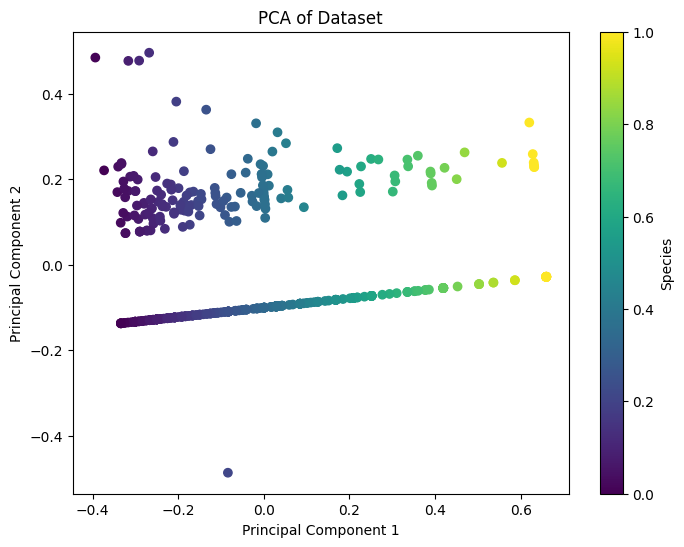

In [ ]:
# 9. Feature Importance
print("\nFeature Importance =================================================================")
# 9. Seleksi Fitur
print("\n Seleksi Fitur =================================================================")
# a. PCA
print("\n a. PCA")
# Load dataset
X = df_normalized.iloc[:, 0:4]
y = df_normalized[0]

# Apply PCA
pca = PCA(n_components=2)  # Menentukan jumlah komponen yang diinginkan
X_pca = pca.fit_transform(X)

# Plot hasil PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Dataset')
plt.colorbar(label='Species')
plt.show()

In [ ]:
# b. Chi Squared
print("\nb. Chi Squared")

df_normalized['label_Cancer'] = pd.cut(df_normalized[0], bins=5, labels=['0', '1', '2', '3', '4'])

# Ambil fitur dan label yang sudah diubah menjadi kategorikal
X = df_normalized.iloc[:, :27]
y = df_normalized['label_Cancer']
# Convert feature names to strings
X.columns = X.columns.astype(str)

# Apply SelectKBest class to extract top 2 best features
best_features = SelectKBest(score_func=chi2, k=2)
X_new = best_features.fit_transform(X, y)

# Show selected features
print(X_new.shape)
print(X_new)


b. Chi Squared
(450, 2)
[[0.10105263157894738 '0']
 [0.25263157894736843 '1']
 [0.35368421052631577 '1']
 [0.5894736842105263 '2']
 [0.4210526315789474 '2']
 [0.11789473684210526 '0']
 [0.15157894736842104 '0']
 [0.2947368421052632 '1']
 [0.1936842105263158 '0']
 [0.5894736842105263 '2']
 [0.7578947368421052 '3']
 [0.1431578947368421 '0']
 [0.07578947368421053 '0']
 [1.0 '4']
 [0.10947368421052632 '0']
 [0.25263157894736843 '1']
 [0.07578947368421053 '0']
 [0.3705263157894737 '1']
 [0.8421052631578947 '4']
 [0.03368421052631579 '0']
 [0.37894736842105264 '1']
 [0.008421052631578954 '0']
 [0.16842105263157897 '0']
 [0.10105263157894738 '0']
 [0.6736842105263158 '3']
 [0.5052631578947367 '2']
 [0.15157894736842104 '0']
 [0.2947368421052632 '1']
 [0.08421052631578947 '0']
 [0.11789473684210526 '0']
 [0.28631578947368425 '1']
 [0.5052631578947367 '2']
 [1.0 '4']
 [0.25263157894736843 '1']
 [0.05052631578947368 '0']
 [0.36509473684210525 '1']
 [0.21052631578947367 '1']
 [0.0842105263157894


Feature Importance =================================================================


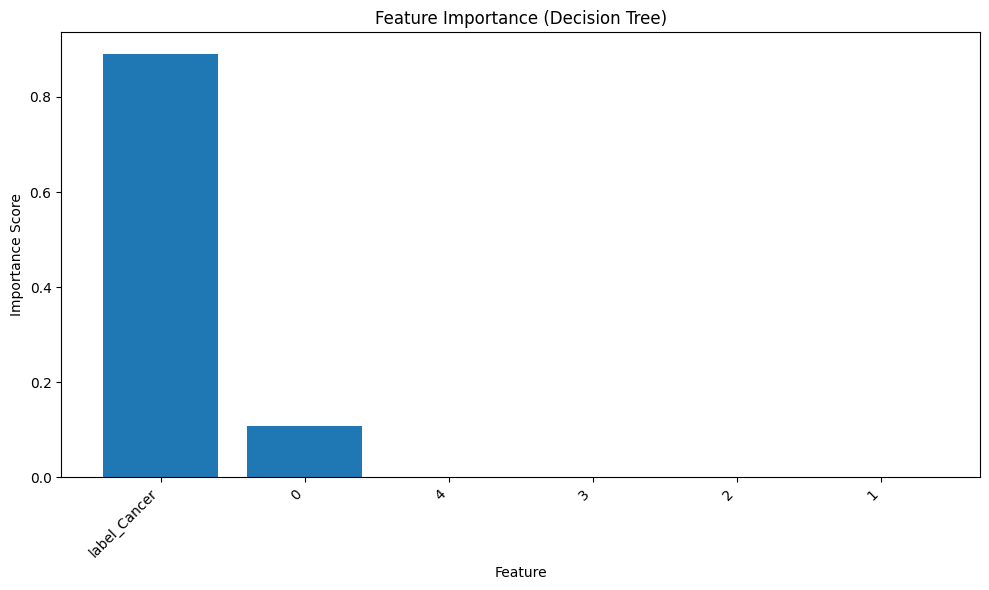

In [ ]:
# 10. Feature Importance
print("\nFeature Importance =================================================================")
from sklearn.tree import DecisionTreeClassifier

# Membuat objek Decision Tree Classifier
model_dt = DecisionTreeClassifier()

# Melatih model dengan fitur dan label yang sudah diubah menjadi kategorikal
model_dt.fit(X, y)

# Mendapatkan nilai feature importance dari model
importances = model_dt.feature_importances_

# Menampilkan feature importance dalam bentuk bar plot
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.title('Feature Importance (Decision Tree)')
plt.tight_layout()
plt.show()


Klasifikasi =================================================================

 Naive Bayes
Naïve Bayes Performance:
Accuracy: 0.9888888888888889
Precision: 0.9945945945945945
Recall: 0.9777777777777779
F1 Score: 0.9854955680902497
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      1.00      0.99        36
           2       1.00      0.89      0.94         9
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         4

    accuracy                           0.99        90
   macro avg       0.99      0.98      0.99        90
weighted avg       0.99      0.99      0.99        90



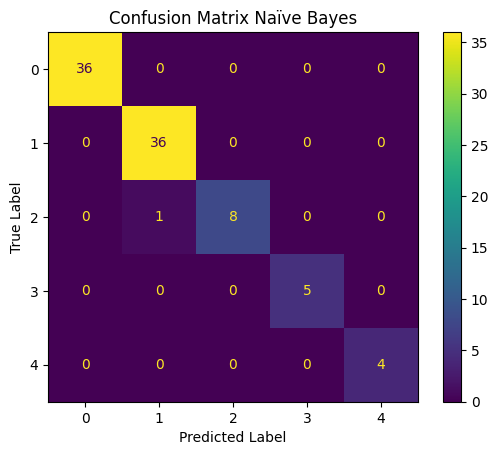

In [ ]:
# 11. Klasifikasi tanpa seleksi fitur
print("\nKlasifikasi =================================================================")
# a. Naive Bayes
print("\n Naive Bayes")
# Importing necessary libraries
import sys
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler  # Add this import statement for StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming that you have already performed data preprocessing steps like handling missing values, encoding categorical variables, etc.
# Define X and y
X = df_normalized.drop(columns=['label_Cancer'])  # Assuming 'label_Cancer' is the target variable
y = df_normalized['label_Cancer']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values in X_train and X_test if necessary
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_imputed_scaled = scaler.fit_transform(X_train_imputed)
X_test_imputed_scaled = scaler.transform(X_test_imputed)

# Initialize and train the Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_imputed_scaled, y_train)
nb_y_pred = nb_classifier.predict(X_test_imputed_scaled)

# Evaluate Naive Bayes classifier
print("Naïve Bayes Performance:")
print("Accuracy:", accuracy_score(y_test, nb_y_pred))
print("Precision:", precision_score(y_test, nb_y_pred, average='macro'))
print("Recall:", recall_score(y_test, nb_y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, nb_y_pred, average='macro'))
print(classification_report(y_test, nb_y_pred))

# Visualize Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, nb_y_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=np.unique(y_test))
disp_nb.plot()
plt.title("Confusion Matrix Naïve Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


SVM (Support Vector Machine)

SVM Performance:
Accuracy: 0.9666666666666667
Precision: 0.9837837837837838
Recall: 0.95
F1 Score: 0.9640410958904109
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.95      0.97      0.96        36
           2       1.00      0.78      0.88         9
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         4

    accuracy                           0.97        90
   macro avg       0.98      0.95      0.96        90
weighted avg       0.97      0.97      0.97        90



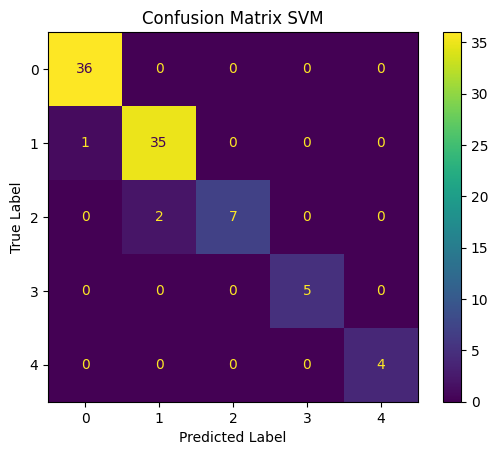

In [ ]:
# b. SVM (Support Vector Machine)
print("\nSVM (Support Vector Machine)")
from sklearn.svm import SVC

# Initialize and train the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)  # You can change the kernel type if needed
svm_classifier.fit(X_train_imputed_scaled, y_train)
svm_y_pred = svm_classifier.predict(X_test_imputed_scaled)

# Evaluate SVM classifier
print("\nSVM Performance:")
print("Accuracy:", accuracy_score(y_test, svm_y_pred))
print("Precision:", precision_score(y_test, svm_y_pred, average='macro'))
print("Recall:", recall_score(y_test, svm_y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, svm_y_pred, average='macro'))
print(classification_report(y_test, svm_y_pred))

# Visualize Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, svm_y_pred)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=np.unique(y_test))
disp_svm.plot()
plt.title("Confusion Matrix SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) Performance:
Accuracy: 0.9777777777777777
Precision: 0.9894736842105264
Recall: 0.9888888888888889
F1 Score: 0.9888803088803089
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        36
           1       1.00      0.94      0.97        36
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         4

    accuracy                           0.98        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.98      0.98      0.98        90



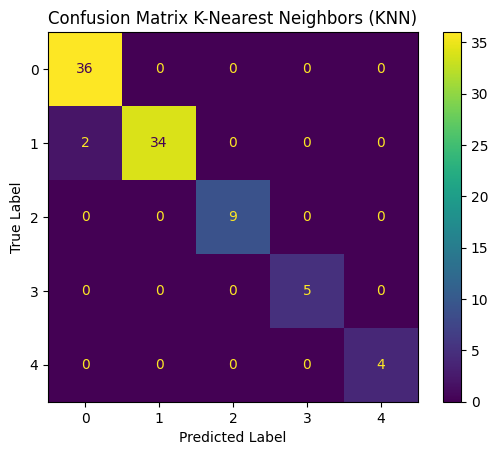

In [ ]:
# c. K-Nearest Neighbors (KNN)
print("\nK-Nearest Neighbors (KNN)")
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # You can change the number of neighbors if needed
knn_classifier.fit(X_train_imputed_scaled, y_train)
knn_y_pred = knn_classifier.predict(X_test_imputed_scaled)

# Evaluate KNN classifier
print("\nK-Nearest Neighbors (KNN) Performance:")
print("Accuracy:", accuracy_score(y_test, knn_y_pred))
print("Precision:", precision_score(y_test, knn_y_pred, average='macro'))
print("Recall:", recall_score(y_test, knn_y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, knn_y_pred, average='macro'))
print(classification_report(y_test, knn_y_pred))

# Visualize Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, knn_y_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=np.unique(y_test))
disp_knn.plot()
plt.title("Confusion Matrix K-Nearest Neighbors (KNN)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Neural Network (Keras)
Epoch 1/50
9/9 [==============================] - 2s 49ms/step - loss: 1.5731 - accuracy: 0.2674 - val_loss: 1.4640 - val_accuracy: 0.5417
Epoch 2/50
9/9 [==============================] - 0s 10ms/step - loss: 1.3951 - accuracy: 0.6181 - val_loss: 1.3166 - val_accuracy: 0.6389
Epoch 3/50
9/9 [==============================] - 0s 8ms/step - loss: 1.2509 - accuracy: 0.7222 - val_loss: 1.1768 - val_accuracy: 0.6806
Epoch 4/50
9/9 [==============================] - 0s 11ms/step - loss: 1.1096 - accuracy: 0.7014 - val_loss: 1.0445 - val_accuracy: 0.6667
Epoch 5/50
9/9 [==============================] - 0s 11ms/step - loss: 0.9817 - accuracy: 0.6910 - val_loss: 0.9311 - val_accuracy: 0.6667
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 0.8730 - accuracy: 0.6979 - val_loss: 0.8348 - val_accuracy: 0.7361
Epoch 7/50
9/9 [==============================] - 0s 11ms/step - loss: 0.7807 - accuracy: 0.7465 - val_loss: 0.7553 - val_accuracy: 0.7917
Epoc

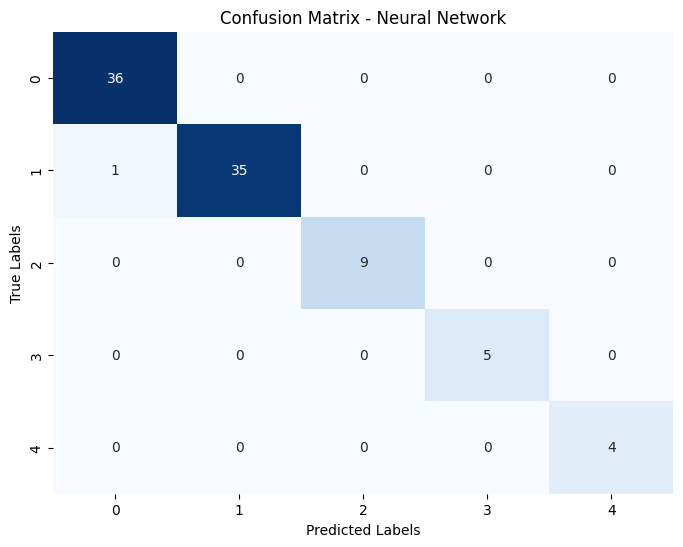

In [ ]:
# d. Neural Network (Keras)
print("\nNeural Network (Keras)")
X_train_imputed_scaled, X_test_imputed_scaled, y_train, y_test

from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode target variable y_train and y_test
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize the Neural Network model
nn_classifier = Sequential()

# Add input layer and first hidden layer
nn_classifier.add(Dense(units=128, activation='relu', input_dim=X_train_imputed_scaled.shape[1]))

# Add second hidden layer
nn_classifier.add(Dense(units=64, activation='relu'))

# Add output layer
# Change units to the number of classes in your encoded target variable
nn_classifier.add(Dense(units=len(np.unique(y_train_encoded)), activation='softmax'))

# Compile the Neural Network model
nn_classifier.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the Neural Network model with encoded target variable
nn_classifier.fit(X_train_imputed_scaled, y_train_encoded, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

# Evaluate Neural Network classifier
nn_loss, nn_accuracy = nn_classifier.evaluate(X_test_imputed_scaled, y_test_encoded)
print("\nNeural Network Performance:")
print("Loss:", nn_loss)
print("Accuracy:", nn_accuracy)

from sklearn.metrics import confusion_matrix

# Predict probabilities for each class using the trained Neural Network model
nn_y_pred_probabilities = nn_classifier.predict(X_test_imputed_scaled)

# Convert probabilities to predicted class labels (assuming one-hot encoding was used)
nn_y_pred = np.argmax(nn_y_pred_probabilities, axis=1)

# Generate the confusion matrix
cm_nn = confusion_matrix(y_test_encoded, nn_y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Neural Network')
plt.show()